# Simulated quantum annealing for MaxCut

Start in the ground state of a transverse field, slowly turn it off while turning on the MaxCut Hamiltonian, and see how the anneal time controls the result. The code lives in `src/annealer.py`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from src.annealer import anneal

cut 6 of 6, P(maximum cut) = 97.4%


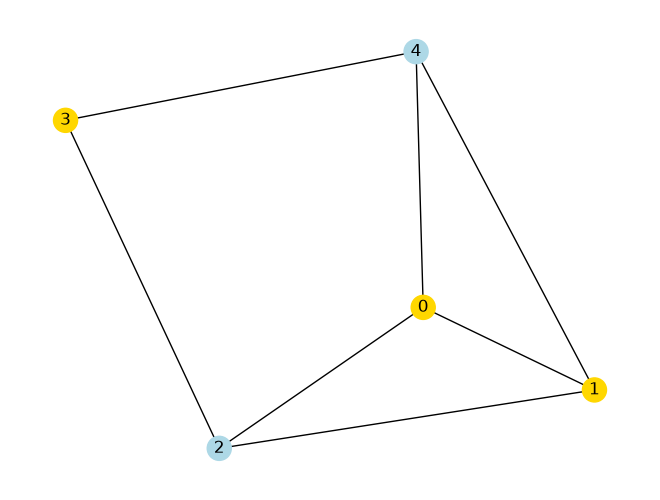

In [2]:
graph = nx.Graph([(0, 1), (1, 2), (2, 3), (3, 4), (4, 0), (0, 2), (1, 4)])
pos = nx.spring_layout(graph, seed=42)
result = anneal(graph, total_time=10)
print(f"cut {result.best_cut:g} of {result.max_cut:g}, P(maximum cut) = {result.success_probability:.1%}")

colors = ["gold" if result.best_assignment[n] else "lightblue" for n in graph.nodes]
nx.draw(graph, pos, with_labels=True, node_color=colors)

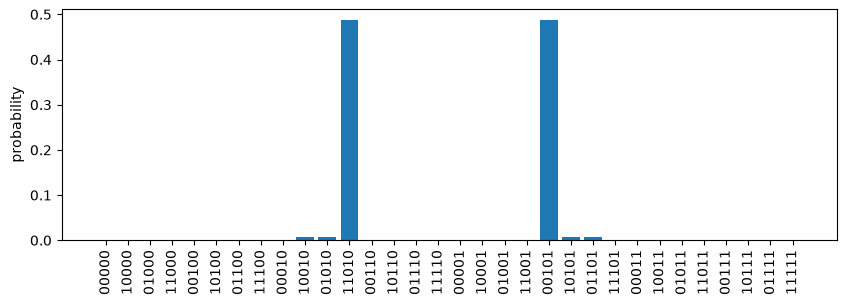

In [3]:
labels = [format(i, "05b")[::-1] for i in range(32)]  # node 0 first
plt.figure(figsize=(10, 3))
plt.bar(labels, result.probabilities)
plt.xticks(rotation=90)
plt.ylabel("probability");

## Slow is good

The adiabatic theorem needs the sweep to be slow compared with the smallest energy gap along the way. Short anneals leave the state spread over excited states.

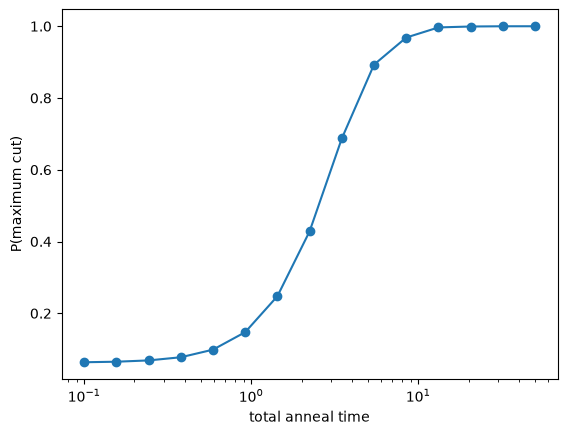

In [4]:
times = np.geomspace(0.1, 50, 15)
plt.semilogx(times, [anneal(graph, total_time=t).success_probability for t in times], "o-")
plt.xlabel("total anneal time")
plt.ylabel("P(maximum cut)");